In [3]:
import numpy as np
import matplotlib.pyplot as plt

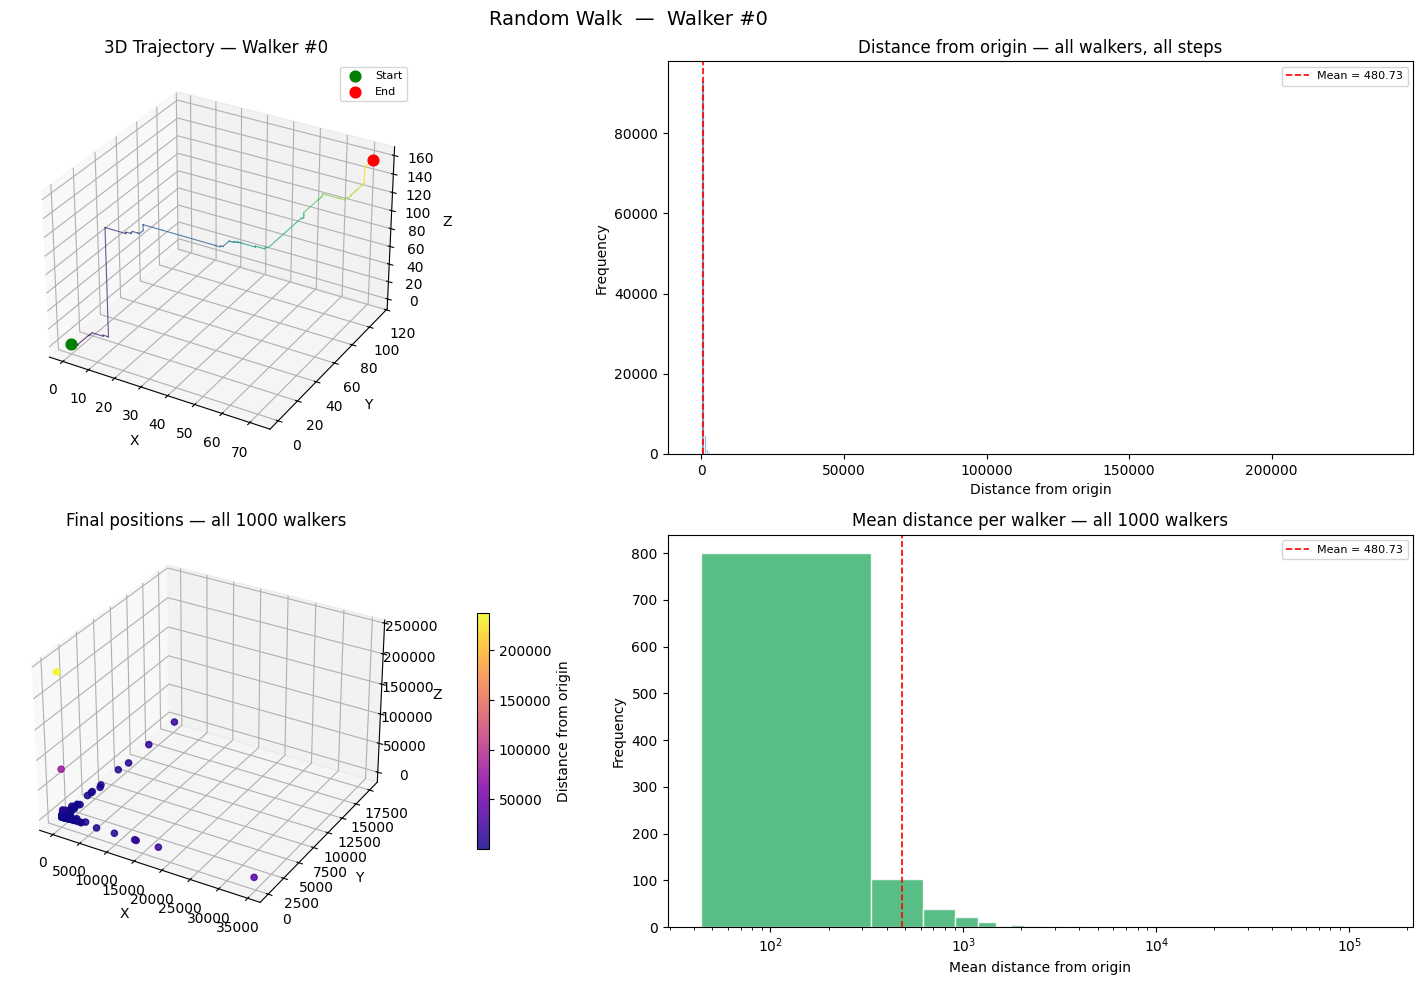

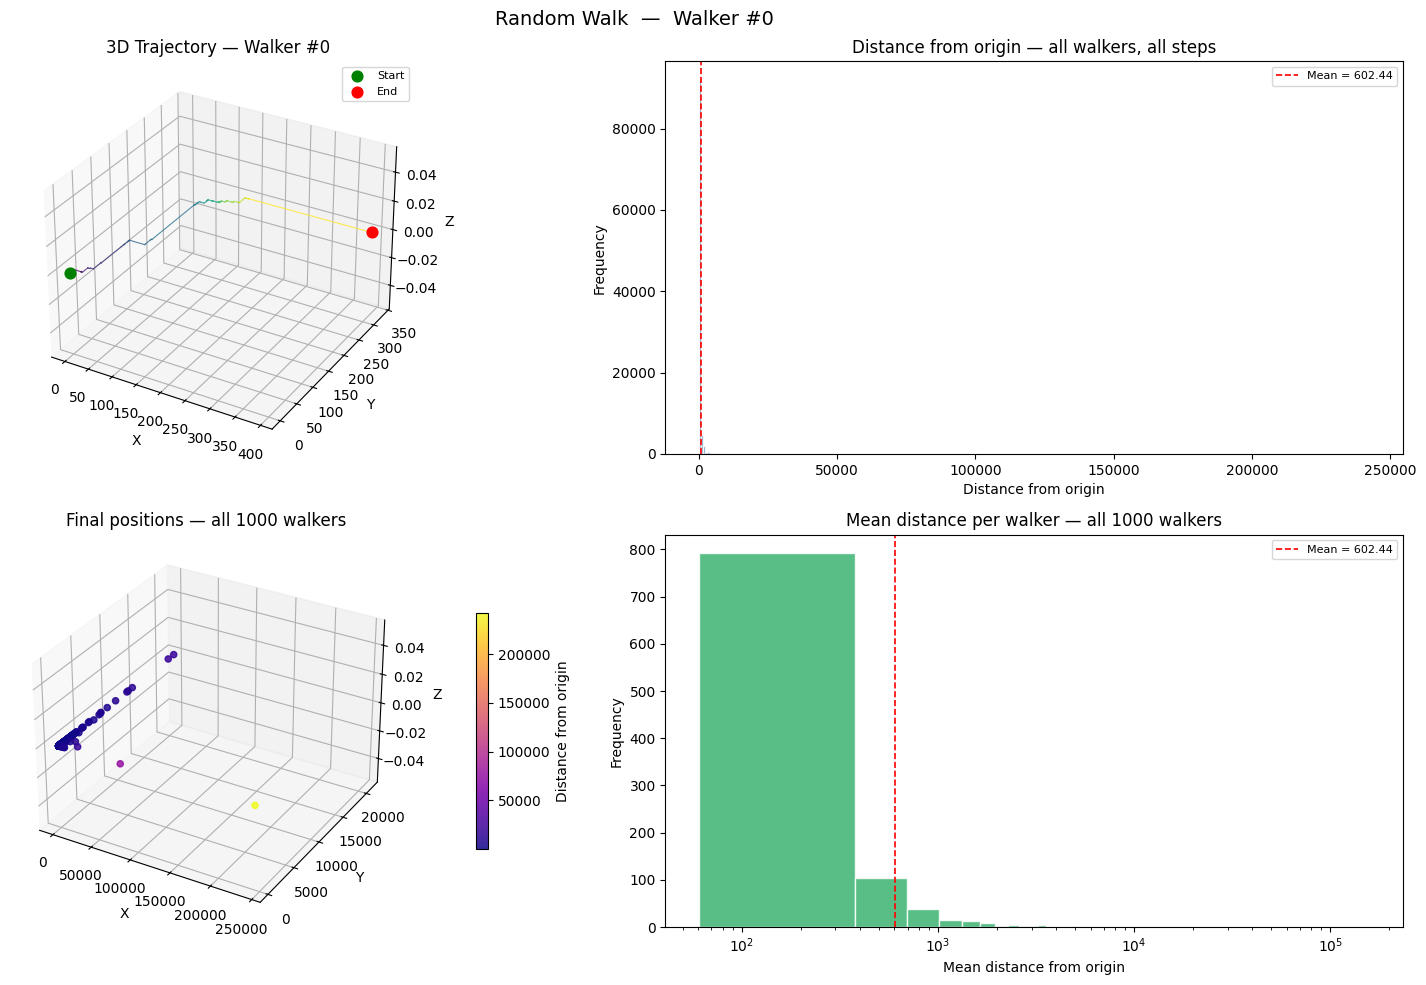

In [ ]:
class RandomWalk():
    def __init__(self, shape_a:float = 1.,  nwalkers:int =10, nsteps:int =10, dimension:int= 3):
        self._Ndim=dimension
        self._a=shape_a
        self._walkers=nwalkers
        self._steps=nsteps
        self._r=np.zeros((self._Ndim, self._walkers, self._steps+1))
    
    def Walking(self):
        movedim=np.random.choice(self._Ndim, (self._walkers, self._steps))
        length=np.random.pareto(self._a, (self._walkers, self._steps))

        w_idx = np.arange(self._walkers)[:, None]   # (walkers, 1)
        s_idx = np.arange(self._steps)  [None, :]   # (1, steps)

        self._r[movedim, w_idx, s_idx + 1] = length
        
        # for w in range(self._walkers):
        #     for s in range(self._steps):
        #         self._r[movedim[w, s], w, s+1]=length[w, s]
        
        self._r = np.cumsum(self._r, axis=2)
        return self._r

    def Save_pickle(self, namefile="Randomwalk.pkl"):
        import pickle
        with open(namefile, "wb") as f:
            pickle.dump(self._r, f) 
        print("Saving completed in file " + namefile)

    def Display(self, walker_index: int = 0):
        r = self._r  # shape: (n_dims, n_walkers, n_steps+1)
        n_dims, n_walkers, n_steps = r.shape

        if walker_index < 0 or walker_index >= n_walkers:
            raise IndexError(f"walker_index={walker_index} out of range [0, {n_walkers - 1}]")

        if n_dims < 3:
            pad = np.zeros((3 - n_dims, n_walkers, n_steps))
            r = np.concatenate([r, pad], axis=0)

        fig = plt.figure(figsize=(16, 10))
        fig.suptitle(f"Random Walk  —  Walker #{walker_index}", fontsize=14)

        # 1. 3D trajectory of selected walker
        ax1 = fig.add_subplot(2, 2, 1, projection="3d")
        x = r[0, walker_index, :]
        y = r[1, walker_index, :]
        z = r[2, walker_index, :]

        colors = plt.cm.viridis(np.linspace(0, 1, n_steps - 1))
        for i in range(n_steps - 1):
            ax1.plot(x[i:i+2], y[i:i+2], z[i:i+2], color=colors[i], linewidth=0.8, alpha=0.8)

        ax1.scatter(*[x[0], y[0], z[0]], color="green", s=60, zorder=5, label="Start")
        ax1.scatter(*[x[-1], y[-1], z[-1]], color="red", s=60, zorder=5, label="End")
        ax1.set_title(f"3D Trajectory — Walker #{walker_index}")
        ax1.set_xlabel("X")
        ax1.set_ylabel("Y")
        ax1.set_zlabel("Z")
        ax1.legend(fontsize=8)
        # 2. 1D histogram of distances at every step — all walkers
        ax2 = fig.add_subplot(2, 2, 2)
        traj_all = r.reshape(3, -1)                          # (3, n_walkers * n_steps)
        dist_all = np.linalg.norm(traj_all, axis=0)         # (n_walkers * n_steps,)
        bins2 = int(np.ceil(np.sqrt(dist_all.size)))
        ax2.hist(dist_all, bins=bins2, color="steelblue", edgecolor="white", alpha=0.85)
        ax2.axvline(dist_all.mean(), color="red", linestyle="--", linewidth=1.2,
                    label=f"Mean = {dist_all.mean():.2f}")
        ax2.set_title("Distance from origin — all walkers, all steps")
        ax2.set_xlabel("Distance from origin")
        ax2.set_ylabel("Frequency")
        ax2.legend(fontsize=8)

        # 3. 3D scatter of final positions colored by distance from origin
        ax3 = fig.add_subplot(2, 2, 3, projection="3d")
        final_pos = r[:, :, -1]                              # (3, n_walkers)
        final_dist = np.linalg.norm(final_pos, axis=0)      # (n_walkers,)
        sc = ax3.scatter(final_pos[0], final_pos[1], final_pos[2],
                         c=final_dist, cmap="plasma", s=20, alpha=0.85)
        fig.colorbar(sc, ax=ax3, label="Distance from origin", pad=0.1, shrink=0.6)
        ax3.set_title(f"Final positions — all {n_walkers} walkers")
        ax3.set_xlabel("X")
        ax3.set_ylabel("Y")
        ax3.set_zlabel("Z")

        # 4. 1D histogram of mean distance per walker — all walkers
        ax4 = fig.add_subplot(2, 2, 4)
        all_dist = np.linalg.norm(r, axis=0)                # (n_walkers, n_steps)
        mean_dist = all_dist.mean(axis=1)                   # (n_walkers,)
        bins4 = int(n_walkers)
        ax4.set_xscale('log')
        ax4.hist(mean_dist, bins=bins4, color="mediumseagreen", edgecolor="white", alpha=0.85)
        ax4.axvline(mean_dist.mean(), color="red", linestyle="--", linewidth=1.2,
                    label=f"Mean = {mean_dist.mean():.2f}")
        ax4.set_title(f"Mean distance per walker — all {n_walkers} walkers")
        ax4.set_xlabel("Mean distance from origin")
        ax4.set_ylabel("Frequency")
        ax4.legend(fontsize=8)

        plt.tight_layout()
        plt.show()
    
prove=RandomWalk(1, 1000, 100, 3)
prove.Walking()
prove.Display(0)


prove=RandomWalk(1, 1000, 100, 2)
prove.Walking()
prove.Display(0)